#📌 Extracción

In [31]:

import pandas as pd
#Extracción de datos de API
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df = pd.read_json(url)
print(df.head())

   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'InternetService': 'Fiber optic', 'OnlineSecu...   
3  {'I

In [32]:
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformación

In [33]:
import pandas as pd

# separar columnas de diccionarios
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

# Concatenar el df
df = pd.concat([df.drop(columns=['customer','phone','internet','account']),
                customer_df, phone_df, internet_df, account_df], axis=1)
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [34]:
#Comprobación de incoherencias en los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [35]:
#Revisar contenido para buscar incoherencias
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("------")

customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
------
Churn
['No' 'Yes' '']
------
gender
['Female' 'Male']
------
SeniorCitizen
[0 1]
------
Partner
['Yes' 'No']
------
Dependents
['Yes' 'No']
------
tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
------
PhoneService
['Yes' 'No']
------
MultipleLines
['No' 'Yes' 'No phone service']
------
InternetService
['DSL' 'Fiber optic' 'No']
------
OnlineSecurity
['No' 'Yes' 'No internet service']
------
OnlineBackup
['Yes' 'No' 'No internet service']
------
DeviceProtection
['No' 'Yes' 'No internet service']
------
TechSupport
['Yes' 'No' 'No internet service']
------
StreamingTV
['Yes' 'No' 'No internet service']
------
StreamingMovies
['No' 'Yes' 'No internet service']
------
Contract
['One year' 'Month-to-month' '

In [36]:
df.isnull().sum()


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.describe()

,SeniorCitizen,tenure,Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [39]:
#Manejo de inconsistencias
import pandas as pd


# Quitar vacíos de Chur
df = df[df["Churn"] != ""]

# Convertir Charges.Total a numérico
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")

#Eliminar NA
df= df.dropna(subset=["Charges.Total"])

# Eliminar espacios en blanco
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

#Normalizar nombres de columnas
df.columns = df.columns.str.replace(' ', '_').str.replace('.', '_')



df.shape

/tmp/ipykernel_4685/2938870612.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")


(7032, 21)

In [40]:
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [41]:
# Columna de cuentas diarias (Opcional)
# Cuentas_Diarias
df['cuentas_diarias'] = df['Charges_Monthly'] / 30

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [42]:
#Estandarización y transformación de datos (opcional)
# Binarizar
Binarizar = ['Churn','Partner','Dependents','PhoneService','PaperlessBilling']

# binarizar
for col in Binarizar:
    df[col] = df[col].map({'Yes':1, 'No':0})
df['gender'] = df['gender'].map({'Female':0, 'Male':1})

#📊 Carga y análisis

In [43]:
#Análisis Descriptivo

#Columnas númericas
numericas = df[['SeniorCitizen',
                       'Partner',
                       'Dependents',
                       'tenure',
                       'Charges_Monthly',
                       'Charges_Total',
                       'cuentas_diarias']]

# Medidas de estadística descriptiva
desc_numericas = numericas.describe()
desc_numericas

,SeniorCitizen,Partner,Dependents,tenure,Charges_Monthly,Charges_Total,cuentas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,0.482509,0.298493,32.421786,64.798208,2283.300441,2.159940
std,0.368844,0.499729,0.457629,24.545260,30.085974,2266.771362,1.002866
min,0.000000,0.000000,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,0.000000,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,1.000000,1.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,1.000000,72.000000,118.750000,8684.800000,3.958333


In [44]:
#Columnas booleanas
booleanas = df[['Churn',
                'SeniorCitizen',
                'Partner',
                'Dependents',
                'PhoneService',
                'PaperlessBilling']]

# Porcenajes
for col in booleanas.columns:
    print(df[col].value_counts(normalize=True)*100 )


Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64
SeniorCitizen
0    83.759954
1    16.240046
Name: proportion, dtype: float64
Partner
0    51.749147
1    48.250853
Name: proportion, dtype: float64
Dependents
0    70.150739
1    29.849261
Name: proportion, dtype: float64
PhoneService
1    90.32992
0     9.67008
Name: proportion, dtype: float64
PaperlessBilling
1    59.2719
0    40.7281
Name: proportion, dtype: float64


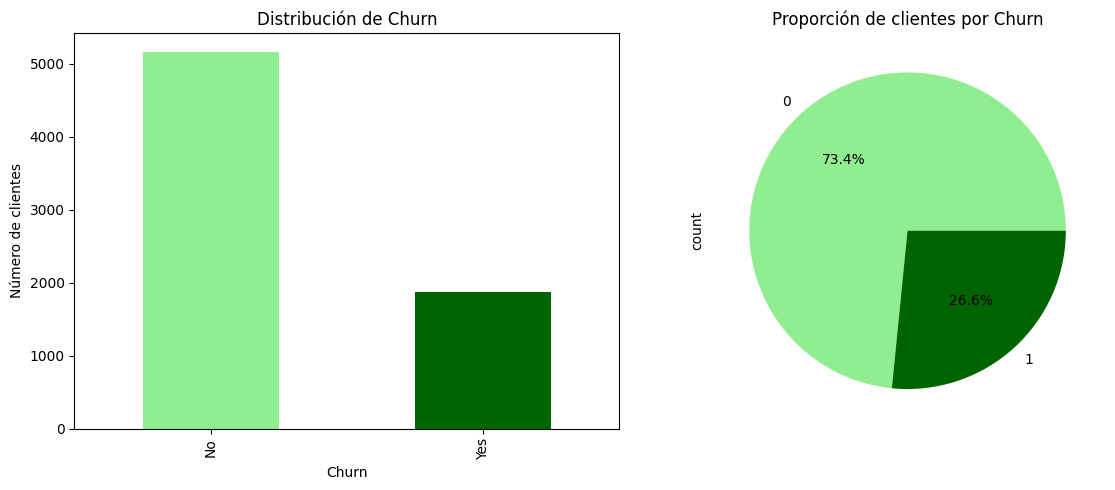

In [45]:
# Distribución de evasión
import matplotlib.pyplot as plt

# Para ver cantidad y porcentaje de Churn
Churn = df['Churn'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

#Gráfico de barras
Churn.plot(kind='bar', color=['lightgreen','darkgreen'], ax=axes[0])
axes[0].set_title('Distribución de Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Número de clientes')
axes[0].set_xticklabels(['No', 'Yes'])

#Gráfico de pastel
Churn.plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen','darkgreen'],ax=axes[1])
axes[1].set_title('Proporción de clientes por Churn')

plt.tight_layout()
plt.show()

In [46]:
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,cuentas_diarias
0,0002-ORFBO,0,0,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,0,1,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,1,1,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,1,1,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,1,0,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,0,0,0,0,13,1,No,DSL,...,No,Yes,No,No,One year,0,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,1,1,0,1,0,22,1,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,1,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,0,1,0,0,0,2,1,No,DSL,...,No,No,No,No,Month-to-month,1,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,0,1,0,1,1,67,1,No,DSL,...,Yes,Yes,No,Yes,Two year,0,Mailed check,67.85,4627.65,2.261667


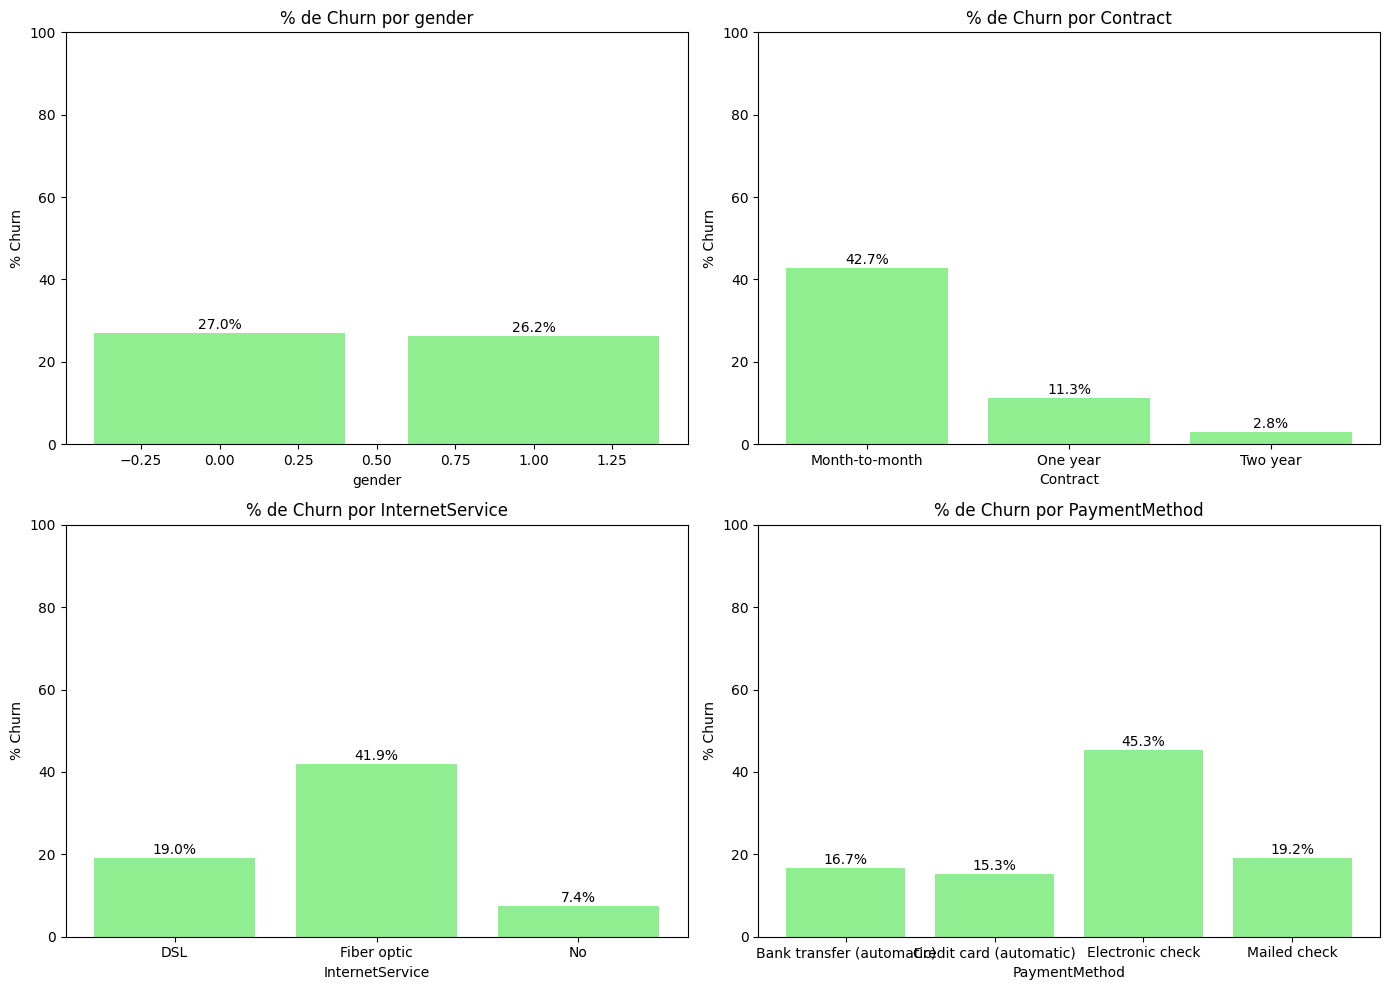

In [47]:
#Recuento de evasión por variables categóricas

import matplotlib.pyplot as plt

# Variables categóricas
categoricas = ['gender', 'Contract', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(categoricas):

    # Porcentaje de churn
    churn_por = df.groupby(col)['Churn'].mean() * 100

    # Gráfico de barras
    axes[i].bar(churn_por.index, churn_por.values, color='lightgreen')

    axes[i].set_title(f'% de Churn por {col}')
    axes[i].set_ylabel('% Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylim(0,100)

    # Etiquetas de porcentaje
    for j, val in enumerate(churn_por.values):
        axes[i].text(j, val + 1, f'{val:.1f}%', ha='center')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4685/3028520788.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([churn_0, churn_1], labels=['No', 'Yes'])
/tmp/ipykernel_4685/3028520788.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([churn_0, churn_1], labels=['No', 'Yes'])
/tmp/ipykernel_4685/3028520788.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([churn_0, churn_1], labels=['No', 'Yes'])
/tmp/ipykernel_4685/3028520788.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped i

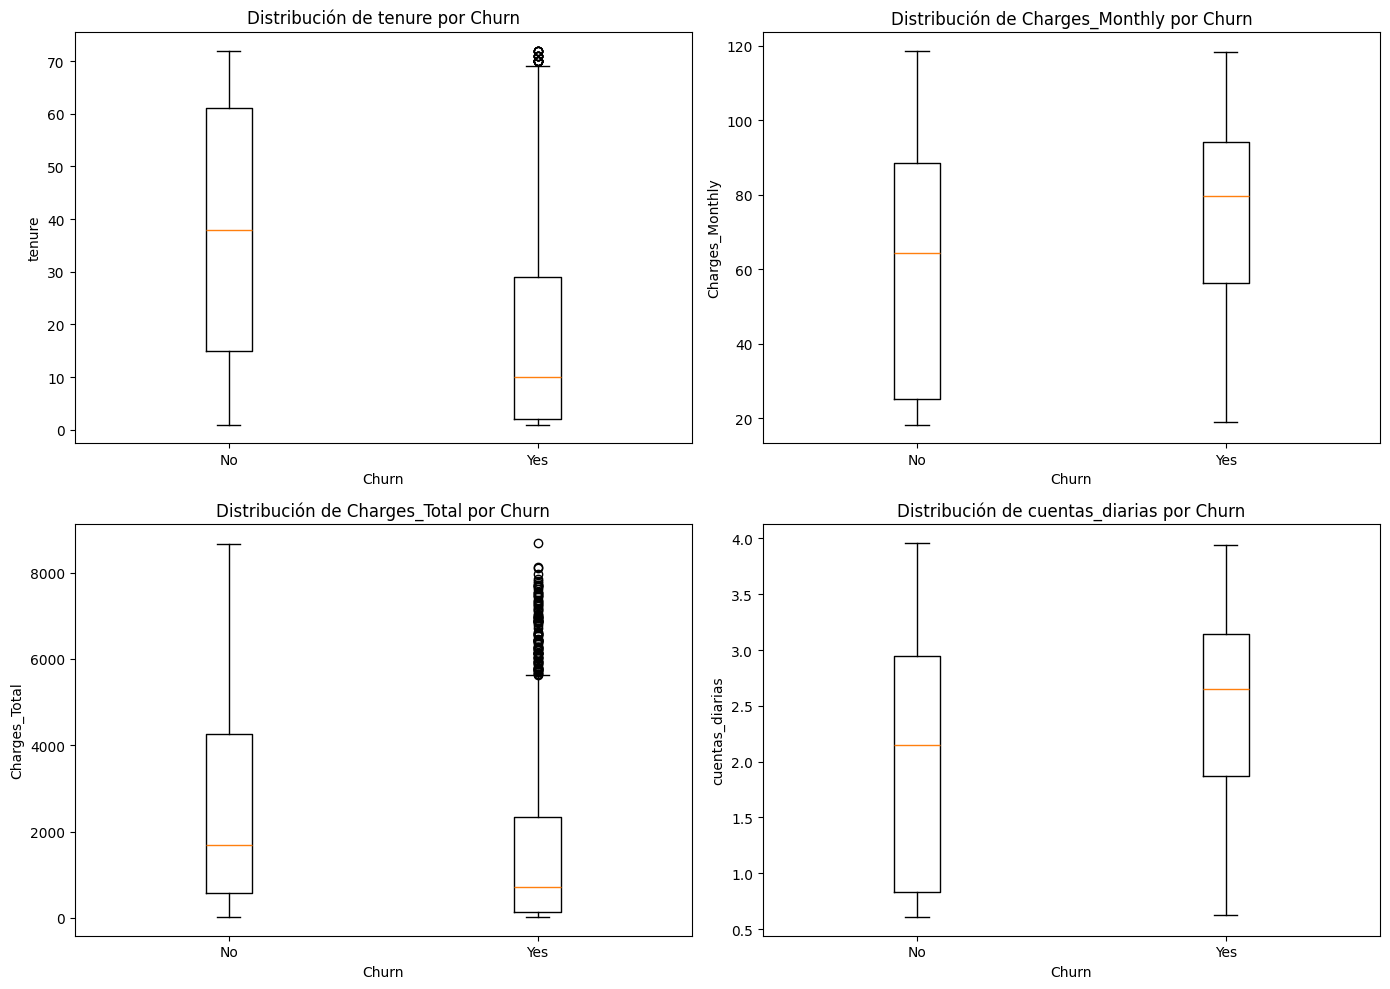

In [48]:
# Conteo de evasión por variables numéricas

import matplotlib.pyplot as plt

# Variables numéricas
numericas = ['tenure', 'Charges_Monthly', 'Charges_Total', 'cuentas_diarias']

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(numericas):
    churn_0 = df[df['Churn'] == 0][col]
    churn_1 = df[df['Churn'] == 1][col]

    # Boxplot con matplotlib
    axes[i].boxplot([churn_0, churn_1], labels=['No', 'Yes'])

    axes[i].set_title(f'Distribución de {col} por Churn')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

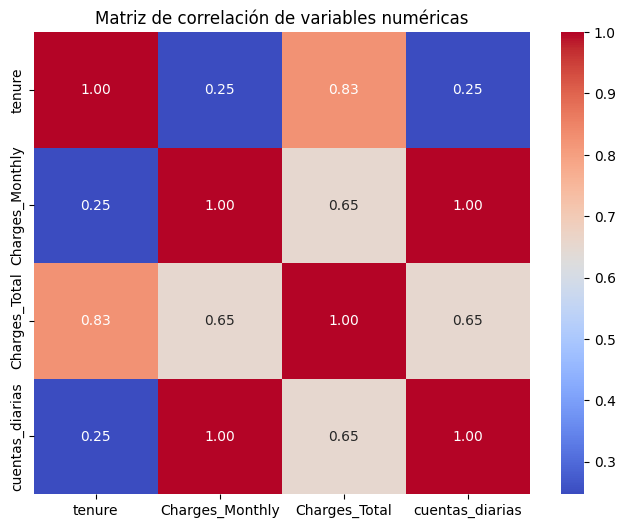

In [49]:
# Análisis de correlación entre variables(Opcional)

import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de correlación
corr_matrix = df[numericas].corr()
corr_matrix

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación de variables numéricas")
plt.show()

In [50]:
df.to_pickle("df_final.pkl")

In [51]:
df.to_csv("df_final.csv", index=False)

#📄Informe final

**Introducción**

El objetivo de este análisis fue estudiar el problema de evasión de clientes  en la empresa TelecomX, con el fin de identificar los factores que influyen en que los usuarios cancelen su servicio. La identificación de patrones permitirá a la empresa anticipar posibles cancelaciones y diseñar estrategias para mejorar la retención de clientes. Para ello se analizaron datos históricos de clientes, considerando variables relacionadas con características del usuario, tipo de contrato, servicios contratados y gastos asociados al servicio.

**Limpieza y Tratamiento de Datos**

En primer lugar, se extrajó el archivo json mediante el API y se transformó en un DataFrame para facilitar su análisis. Posteriormente, se separaron las columnas que contenían información anidada (como datos del cliente, servicio telefónico, internet y cuenta) para convertirlas en columnas independientes y facilitar el manejo de datos. También se revisaron posibles inconsistencias en los datos, como valores vacíos o errores de formato. La columna Charges.Total se convirtió a formato numérico y se eliminaron registros con datos faltantes como aquellas filas de la columna Churn con string vacio. Además, se estandarizaron los nombres de las columnas y se crearon variables adicionales, como el gasto diario promedio, lo que permitió obtener un conjunto de datos limpio con más de siete mil registros listo para el análisis.

**Análisis Exploratorio de Datos**

El análisis exploratorio permitió identificar varios patrones importantes. Aproximadamente el 26.6% de los clientes cancelaron su servicio, mientras que el 73.4% permanecieron activos. Se observó que los clientes con contratos mes a mes presentan una mayor tendencia a cancelar (42.7%) en comparación con quienes tienen contratos de un año (11.3%) o dos años (2.8%), lo que sugiere que los compromisos de mayor duración favorecen la permanencia del cliente.

También se encontró que los clientes con menor tiempo de permanencia en la empresa (tenure) tienen mayor probabilidad de abandonar el servicio. En cuanto al tipo de internet, los usuarios de fibra óptica presentan una mayor tasa de cancelación (41.9%) en comparación con los clientes que utilizan DSL (19%) o quienes no tienen servicio de internet (7.4%).

Asimismo, el método de pago también muestra diferencias importantes. Los clientes que utilizan electronic check presentan la mayor tasa de cancelación (45.3%), mientras que quienes pagan mediante transferencia automática, tarjeta de crédito automática o cheque enviado por correo muestran porcentajes considerablemente menores.

**Conclusión**

Los resultados muestran que la evasión de clientes se concentra principalmente en usuarios nuevos y con contratos de corto plazo, especialmente aquellos con contratos mes a mes, que presentan la mayor tasa de cancelación. También se observó que los clientes con servicio de fibra óptica tienen una probabilidad más alta de abandonar el servicio en comparación con quienes utilizan DSL u otros servicios.

Además, el método de pago parece influir en la cancelación. Los clientes que utilizan electronic check presentan el mayor porcentaje de churn, mientras que quienes pagan mediante transferencias automáticas o tarjeta de crédito automática muestran menores tasas de cancelación. En conjunto, estos resultados permiten identificar perfiles de clientes con mayor riesgo de abandono.

**Recomendaciones**

Con base en estos resultados, se recomienda que TelecomX implemente estrategias enfocadas en retener a los clientes durante sus primeros meses, por ejemplo mediante promociones o beneficios adicionales. También sería conveniente fomentar contratos de mayor duración, ya que estos muestran una menor tasa de cancelación.

Asimismo, la empresa podría analizar con mayor detalle a los clientes que utilizan electronic check, ya que presentan un mayor riesgo de evasión, y ofrecer incentivos o facilidades de pago que ayuden a mejorar su permanencia. Finalmente, utilizar estos hallazgos para segmentar a los clientes con mayor riesgo de abandono permitiría diseñar estrategias de retención más efectivas.